In [1]:
import numpy as np
import scanpy as sc
import anndata as an
import pandas as pd

## Import Data

Initial annotation atttempt using cytok_pf2_30

In [2]:
data = an.read_h5ad("/opt/extra-storage/pf2_results/cytok_pf2_30.h5ad")

In [3]:

types = {
		'Monocytes' : [
			'CD14',
			'CD33',
			'LYZ',
			'FCER1G',
			'LGALS3',
			'CSF1R',
			'ITGAX',
			'ITGAM',
			'CD86',
			'HLA-DRB1'],
		'Dendritic cells' : [
			'LAD1',
			'LAMP3',
			'TSPAN13',
			'CLIC2',
			'FLT3'],
		'B-cells' : [
            'BANK1',
			'MS4A1',
			'CD19',
			'CD79A'],
		'T-helpers' : [
			'TNF',
			'TNFRSF18',
			'IFNG',
			'IL2RA',
			'BATF'],
		'T cells' : [
			'CD27',
			'CD69',
			'CD2',
			'CD3D',
			'CXCR3',
			'CCL5',
			'IL7R',
			'CXCL8',
			'GZMK'],
		'Natural Killers' : [
			'NKG7',
			'GNLY',
			'PRF1',
			'FCGR3A',
			'NCAM1',
			'TYROBP']
	}


In [4]:
print(data)
sc.pp.highly_variable_genes(data, min_mean=0.005, max_mean=10, min_disp=0.5)
adata = data[:, data.var.highly_variable]
print(adata)

AnnData object with n_obs × n_vars = 19747 × 6831
    obs: 'Condition', 'condition_unique_idxs'
    var: 'ENSEMBLE_ids', 'feature_type', 'means'
    uns: 'Pf2_A', 'Pf2_B', 'Pf2_weights'
    obsm: 'X_pf2_PaCMAP', 'projections', 'weighted_projections'
    varm: 'Pf2_C'
View of AnnData object with n_obs × n_vars = 19747 × 2465
    obs: 'Condition', 'condition_unique_idxs'
    var: 'ENSEMBLE_ids', 'feature_type', 'means', 'highly_variable', 'dispersions', 'dispersions_norm'
    uns: 'Pf2_A', 'Pf2_B', 'Pf2_weights', 'hvg'
    obsm: 'X_pf2_PaCMAP', 'projections', 'weighted_projections'
    varm: 'Pf2_C'


/home/nicoleb/Pf2-scRNAseq-1/.venv/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


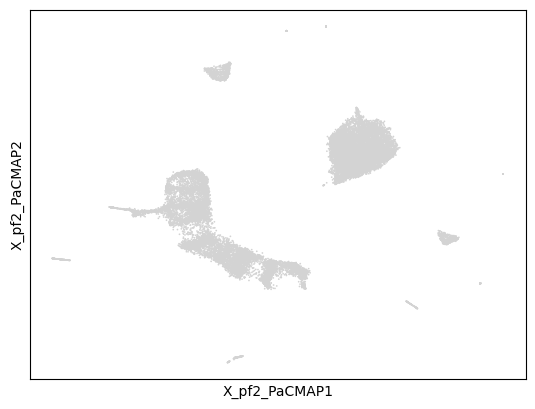

In [6]:
sc.pl.embedding(basis="X_pf2_PaCMAP", adata=adata)

/tmp/ipykernel_342648/1264362392.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, random_state=0, resolution=3.5)


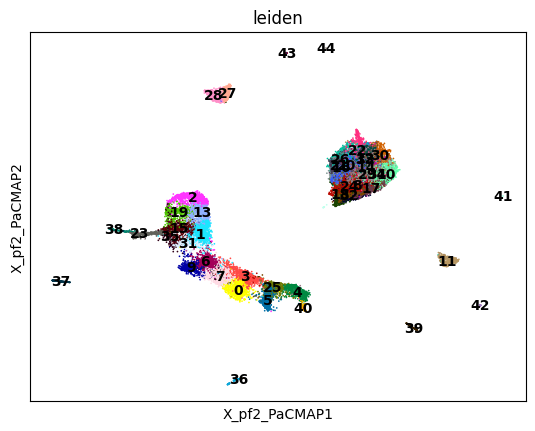

In [5]:
sc.pp.neighbors(adata, use_rep="projections", random_state=0)

sc.tl.leiden(adata, random_state=0, resolution=3.5)
sc.pl.embedding(basis="X_pf2_PaCMAP", adata=adata, color=["leiden"], legend_loc='on data') #basis of cell embedding  use projections form pf2
#tell model how many groupings of interconncected cells you want 
#resolution creates groups, higher more clusters 

In [6]:
sc.pp.neighbors(data, use_rep="projections", random_state=0)
sc.tl.leiden(data, random_state=0, resolution=3.5)

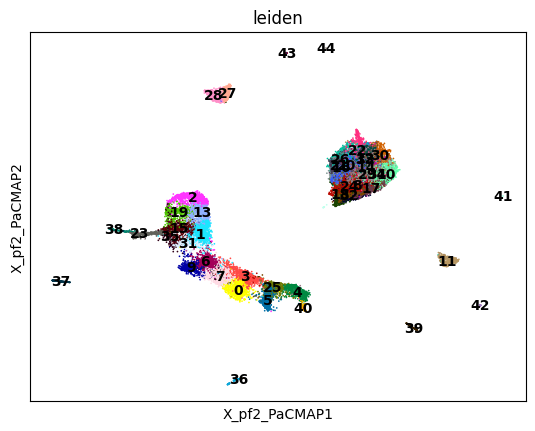

In [7]:
sc.pl.embedding(basis="X_pf2_PaCMAP", adata=data, color=["leiden"], legend_loc='on data') #basis of cell embedding  use projections form pf2

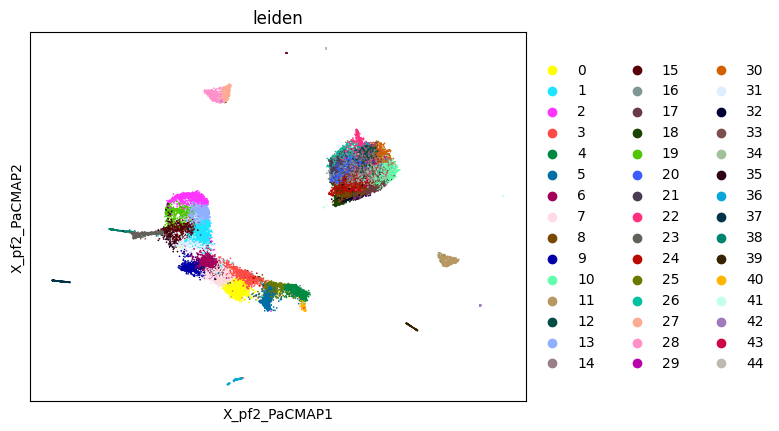

In [8]:
sc.pl.embedding(basis="X_pf2_PaCMAP", adata=adata, color=["leiden"])

KeyError: 'Could not find key CLEC10A in .var_names or .obs.columns.'

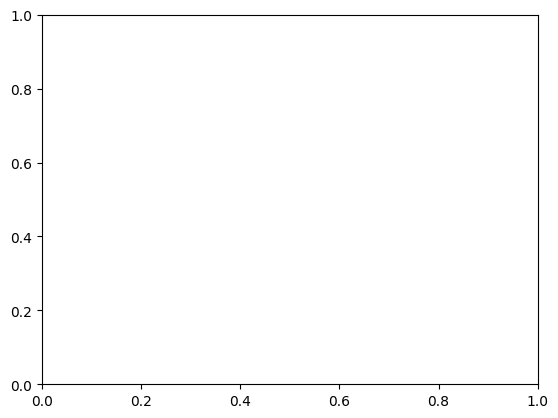

In [42]:
sc.pl.embedding(data, basis="X_pf2_PaCMAP", color=["CLEC10A"])

/home/nicoleb/Pf2-scRNAseq-1/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:435: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/nicoleb/Pf2-scRNAseq-1/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:437: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/nicoleb/Pf2-scRNAseq-1/.venv/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:440: Perform

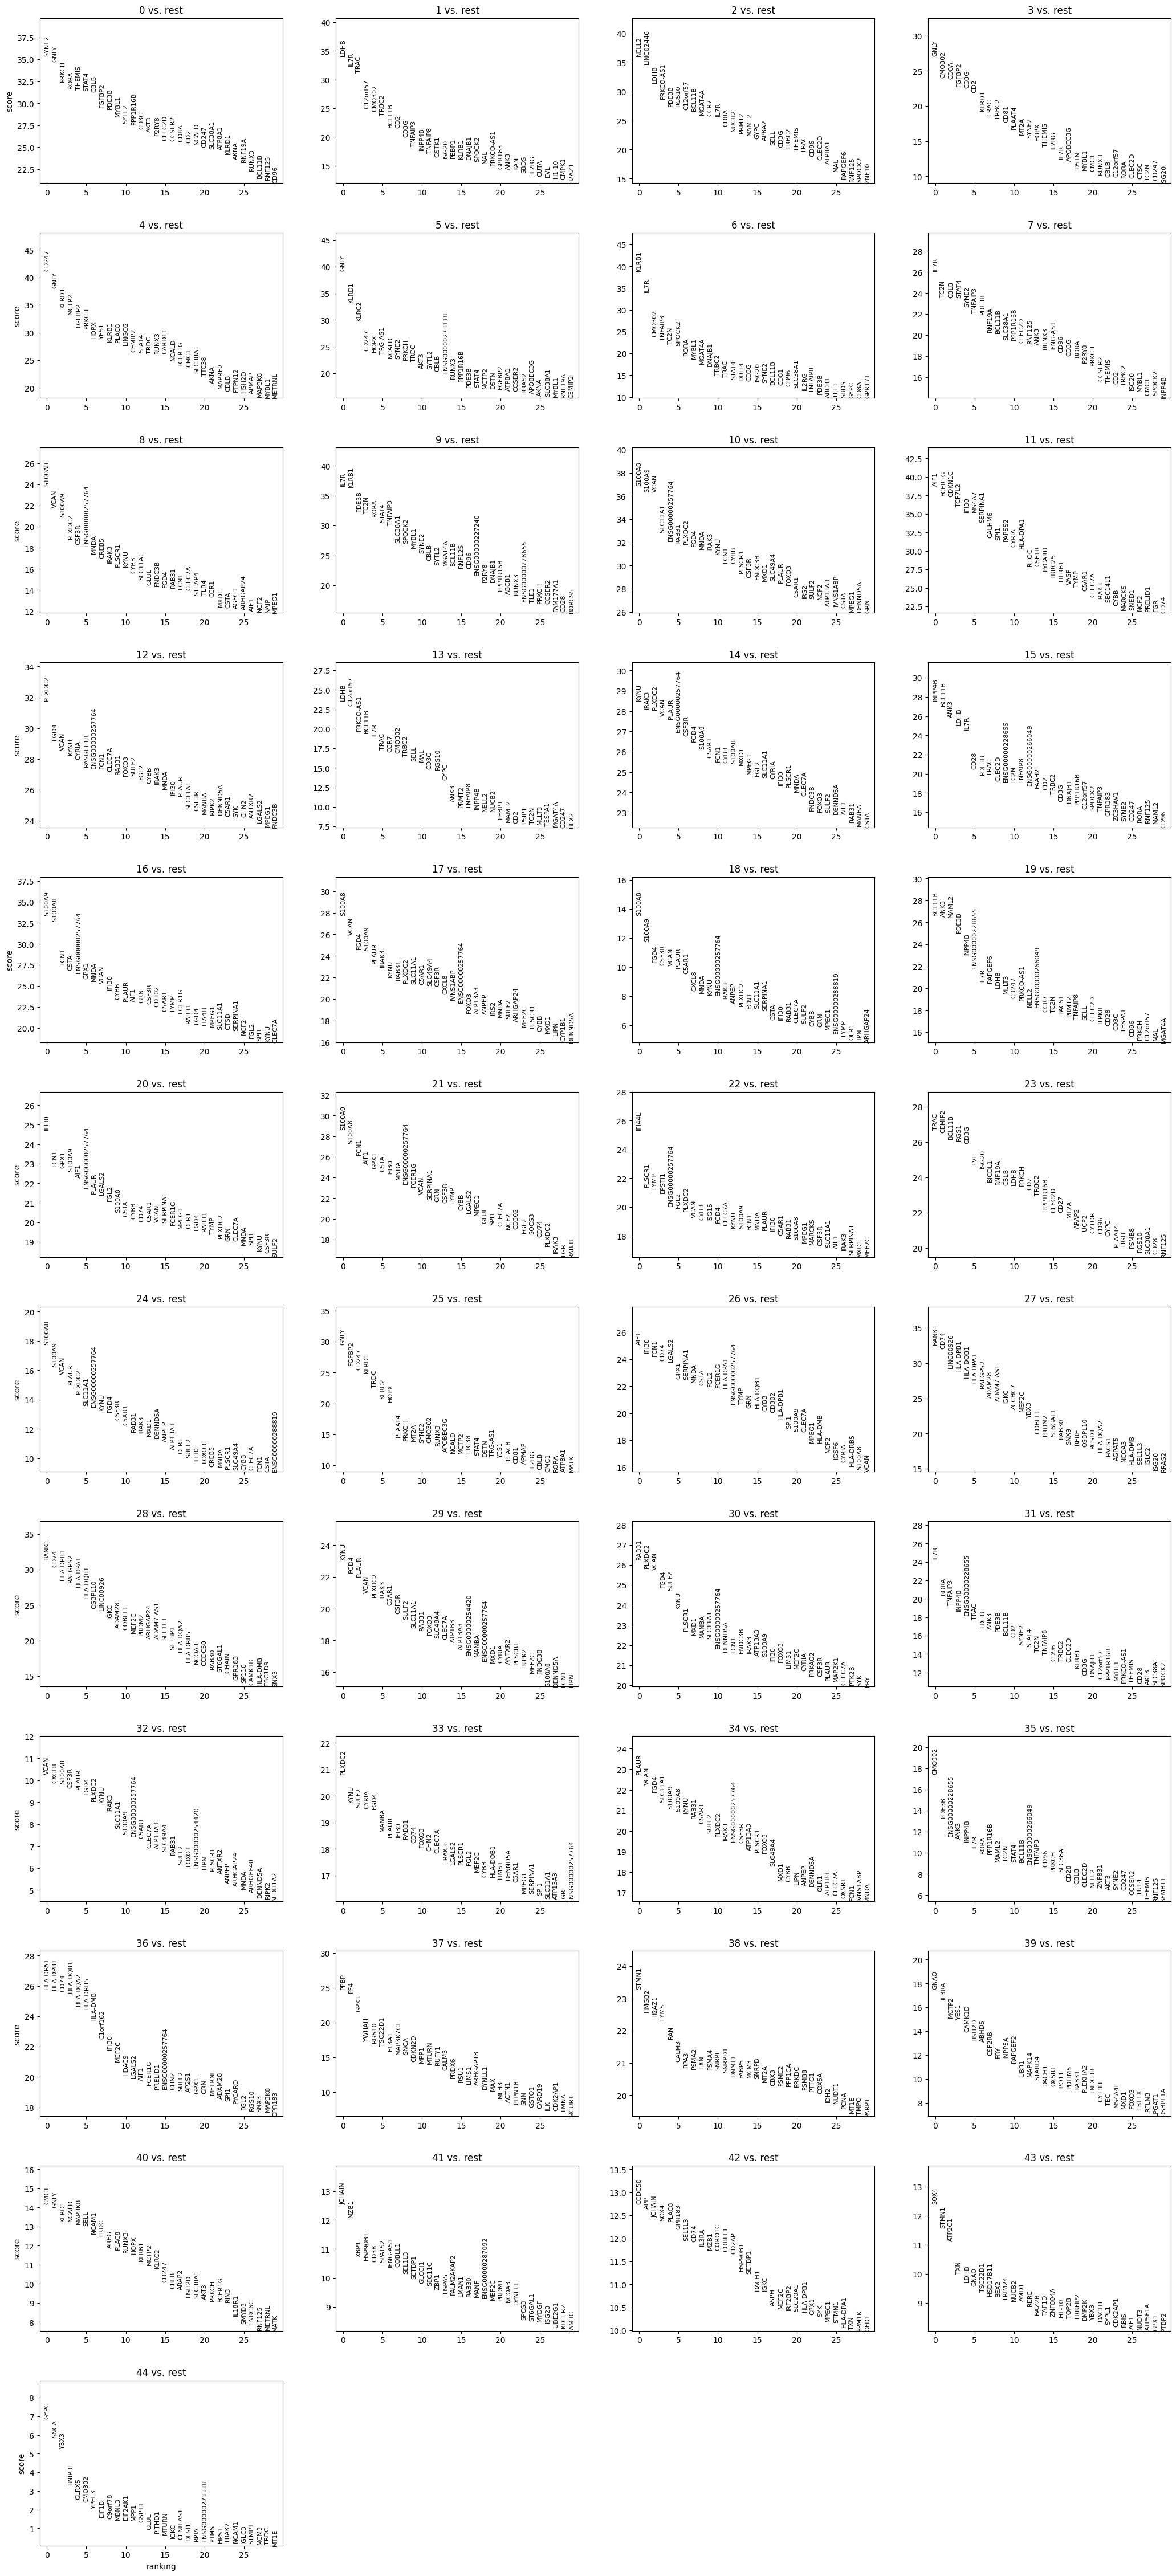

In [8]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=30, sharey=False, save=True)

/home/nicoleb/Pf2-scRNAseq-1/.venv/lib/python3.11/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 2465 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


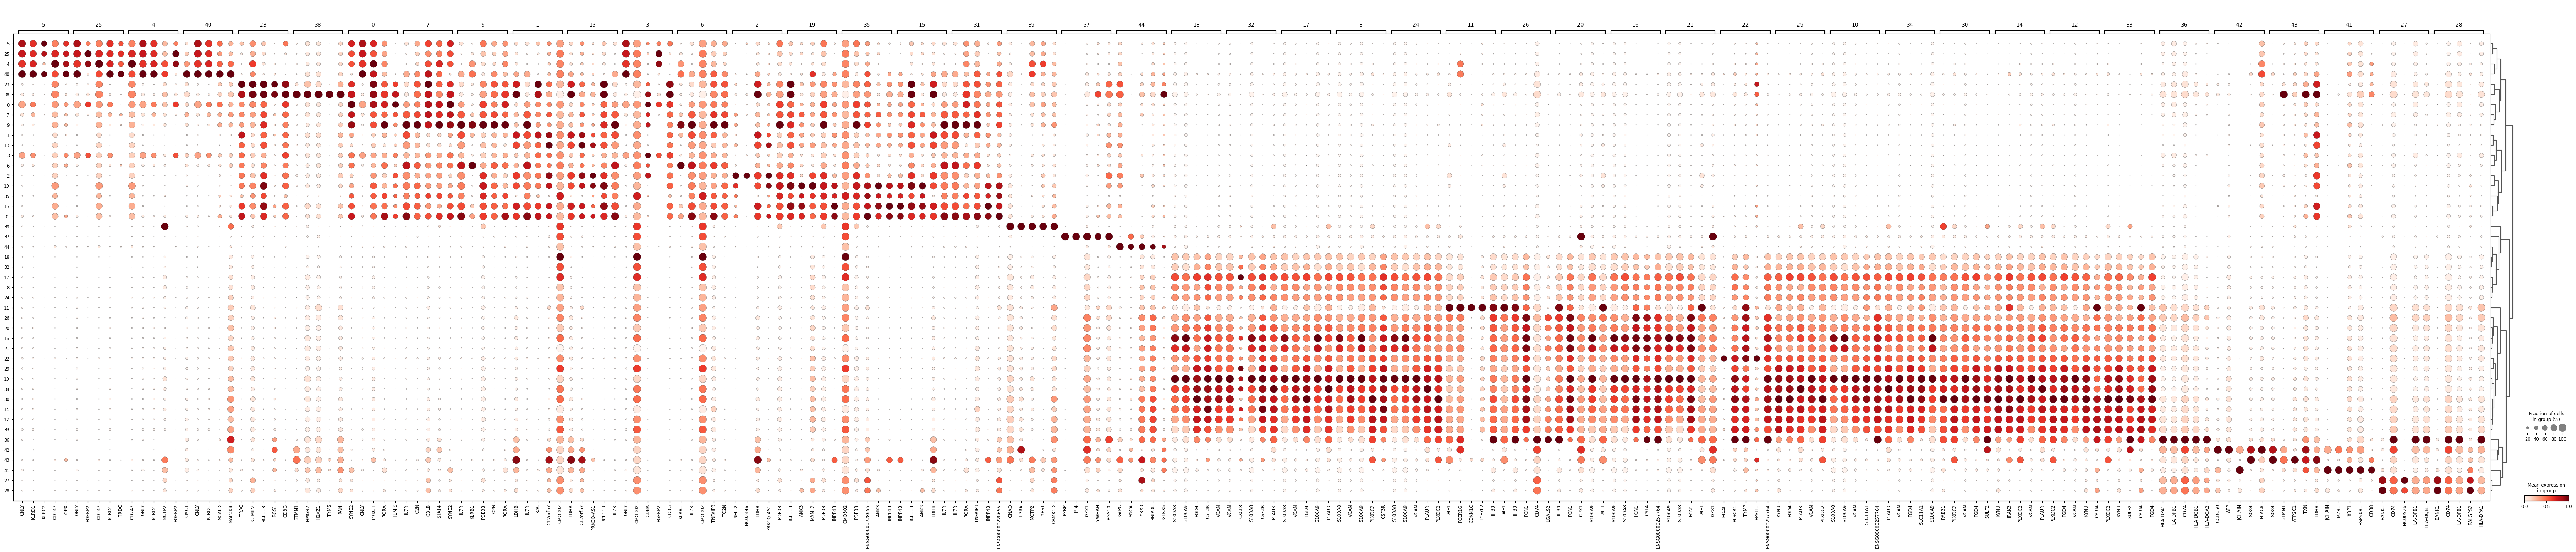

In [9]:
sc.pl.rank_genes_groups_dotplot(
    adata, groupby="leiden", standard_scale="var", n_genes=5
)

In [43]:
cellDF = sc.tl.marker_gene_overlap(adata, types)
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.precision', 3,
                       ):
    print(cellDF)

                   0    1    2    3    4    5    6    7    8    9   10   11  \
Monocytes        0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  1.0  0.0  1.0  2.0   
Dendritic cells  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
B-cells          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
T-helpers        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
T cells          2.0  3.0  3.0  2.0  0.0  1.0  2.0  2.0  1.0  1.0  0.0  0.0   
Natural Killers  1.0  0.0  0.0  1.0  2.0  2.0  0.0  0.0  0.0  0.0  0.0  0.0   

                  12   13   14   15   16   17   18   19   20   21   22   23  \
Monocytes        1.0  0.0  1.0  0.0  1.0  1.0  1.0  0.0  1.0  1.0  1.0  0.0   
Dendritic cells  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
B-cells          0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
T-helpers        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
T cells          0.0  3.0  0.0  2.0  1.0  1.0  1.0 

In [63]:
celltypedict_layer1 = {"0": "T cells",
                       "1": "T cells",
                       "2": "T cells", 
                       "3": "T cells", 
                       "4": "NK",
                       "5": "NK",
                       "6": "T cells", 
                       "7": "T cells",
                       "8": "Monocytes", 
                       "9": "T cells",
                       "10": "Monocytes", 
                       "11": "Monocytes",
                       "12": "Monocytes", 
                       "13": "T cells", 
                       "14": "Monocytes", 
                       "15": "T cells",
                       "16": "Monocytes", 
                       "17": "Monocytes", 
                       "18": "Monocytes", 
                       "19": "T cells",
                       "20": "Monocytes", 
                       "21": "Monocytes", 
                       "22": "Monocytes", 
                       "23": "T cells", 
                       "24": "Monocytes",
                       "25": "NK", 
                       "26": "Monocytes", 
                       "27": "B cells", 
                       "28": "B cells",
                       "29": "Monocytes",
                       "30": "Monocytes",
                       "31": "T cells", 
                       "32": "DC", 
                       "33": "Monocytes", 
                       "34": "Monocytes",
                       "35": "T cells",
                       "36": "DC",
                       "37": "Myeloid",
                       "38": "Prolif",
                       "39": "gran",
                       "40": "NK",
                       "41": "Plasma",
                       "42": "DC",
                       "43": "gran",
                       "44": "NK?",
                       
                       }

print(adata.obs.leiden.replace(celltypedict_layer1))
adata.obs["CellType1"] = adata.obs.leiden.replace(celltypedict_layer1)

AAACCCACAAGACAAT-1      T cells
AAACCCACACTGATTG-1    Monocytes
AAACGAAAGGACAGTC-1    Monocytes
AAACGCTAGGATATGT-1    Monocytes
AAACGCTCAGGTAGTG-1      T cells
                        ...    
TTTGGAGGTGACTAAA-1      T cells
TTTGGTTAGTGGCGAT-1    Monocytes
TTTGGTTTCGACGACC-1      T cells
TTTGGTTTCGTAGCCG-1    Monocytes
TTTGTTGAGGATTCAA-1    Monocytes
Name: leiden, Length: 19747, dtype: category
Categories (10, object): ['T cells', 'NK', 'Monocytes', 'B cells', ..., 'Prolif', 'gran', 'Plasma', 'NK?']


/tmp/ipykernel_3412994/2573492893.py:49: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  print(adata.obs.leiden.replace(celltypedict_layer1))
/tmp/ipykernel_3412994/2573492893.py:50: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["CellType1"] = adata.obs.leiden.replace(celltypedict_layer1)


/home/nicoleb/Pf2-scRNAseq-1/.venv/lib/python3.11/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 2465 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


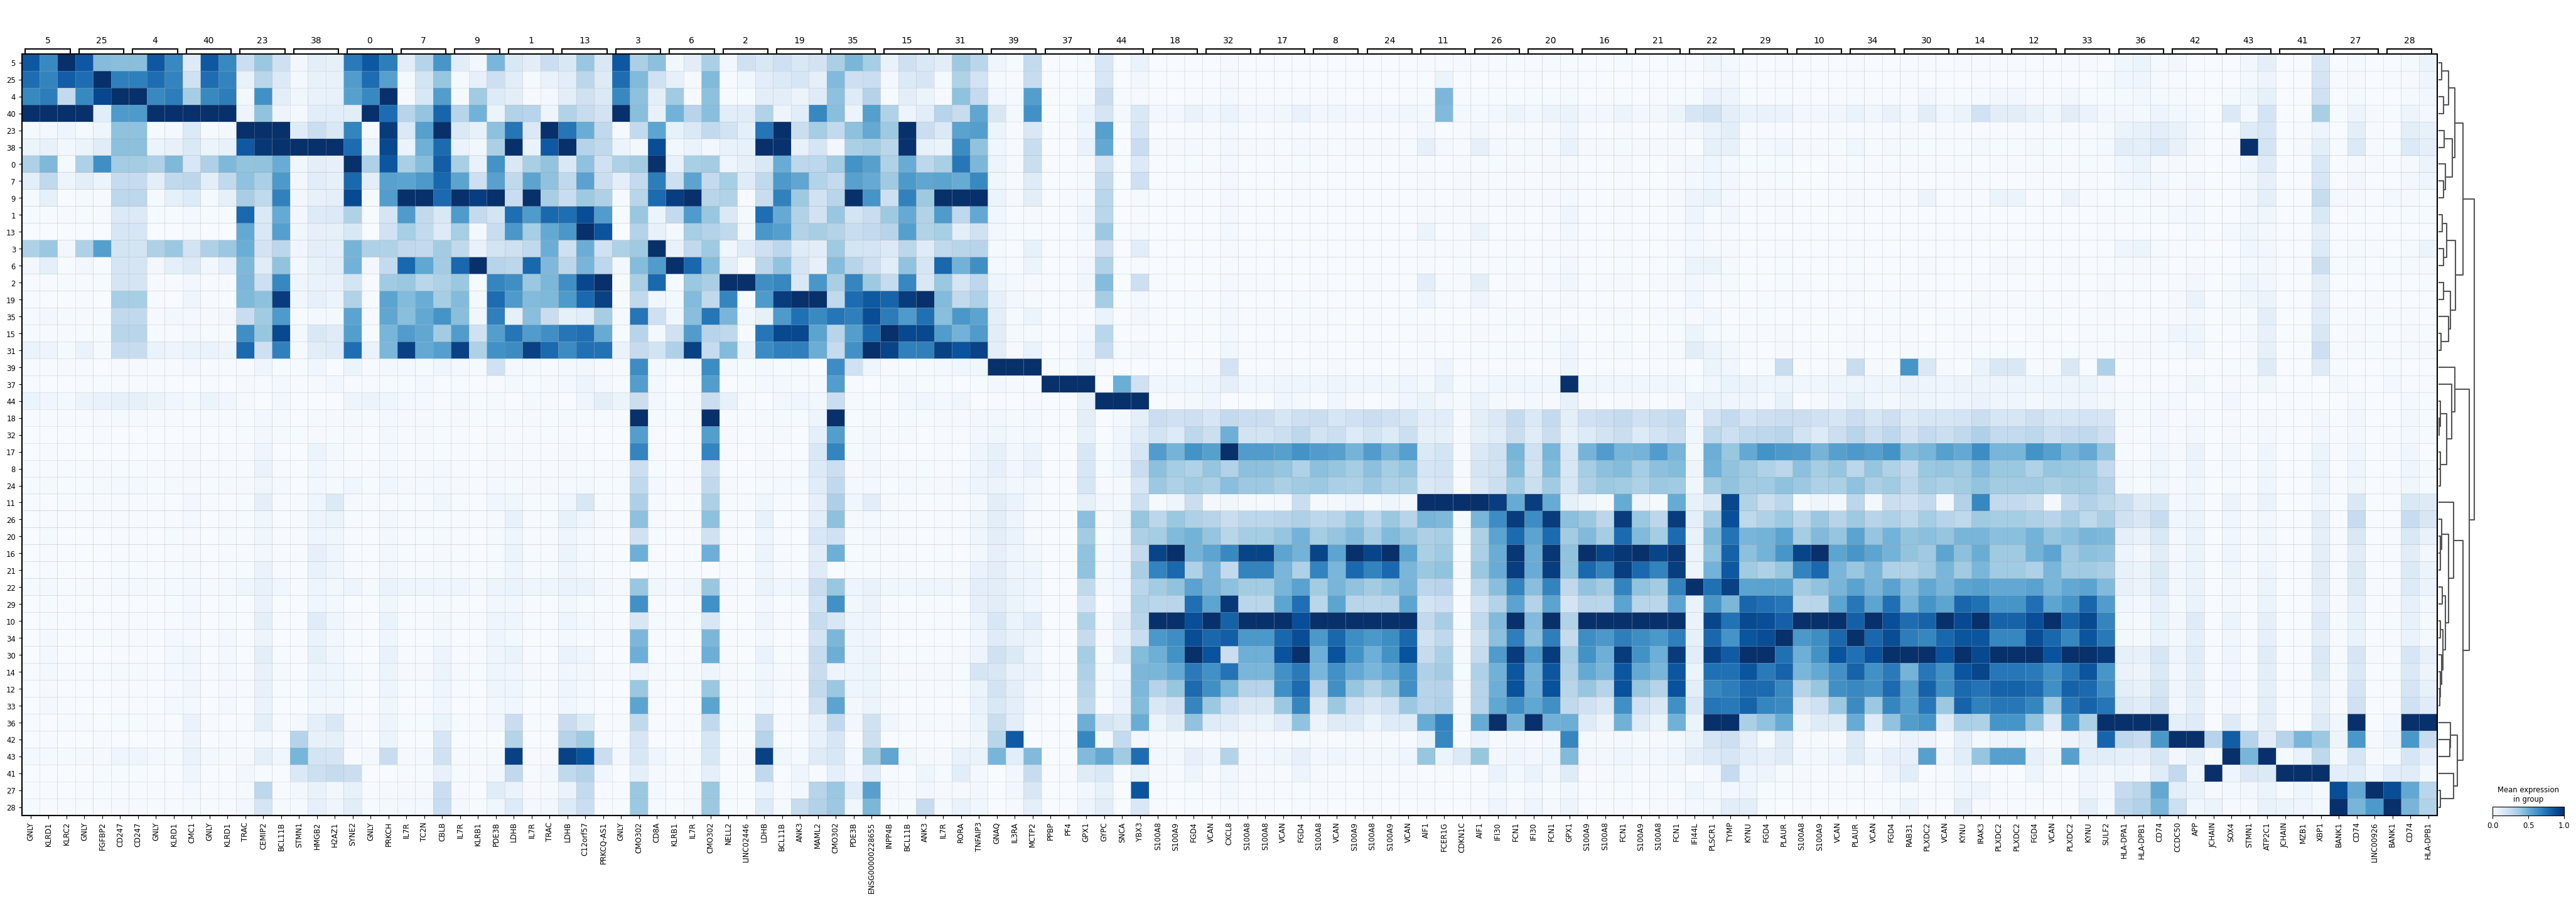

In [22]:
sc.pl.rank_genes_groups_matrixplot(adata, n_genes=3, standard_scale='var', cmap='Blues')

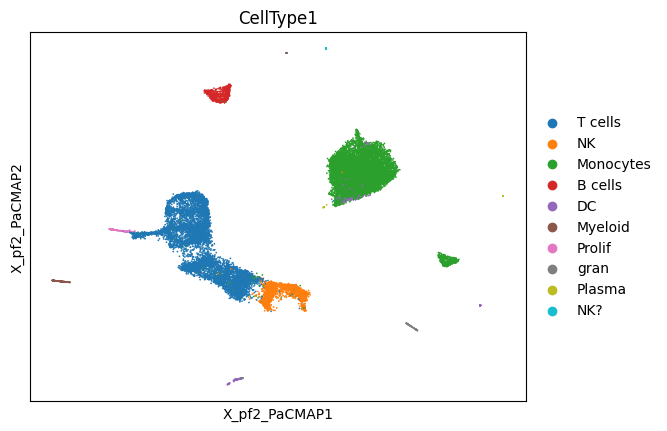

In [20]:
sc.pl.embedding(basis="X_pf2_PaCMAP", adata=adata, color=["CellType1"])

In [162]:
types = {
	'CM' : ['CD14'
          'LYZ',
          'S100A8',
          'S100A9',
          'IL8'],
	'cDC1' : ['LGALGS2',
            'MS4A6A'],
	'cDC2' : ['HLA-DQA1',
            'HLA-DQA2',
            'HLA-DMB'],
	'nCM' : ['FCGR3A'],
	'pDC' : ['SERPINF1',
           'LILRA',
           'IRF8'],
	'B Naive' : ['TCL1A',
              'MS4A1'],
      'B Memory' : ['BANK1'],
      'B Plasma' : ['IGJ',
                      'CD79A',
                      'MZB1'],
      'T4 Naive' : ['CCD7',
                      'MAL',
                      'LEF1'],
      'T4 Reg' : ['ITGB1'],
      'T4 EM' : ['IL7R',
                   'RTKN1'],
      'T8 Naive' : ['CD8A',
                      'CD8B'],
      'T8 GZMK' : ['GZMK',
                     'GNLY'],
      'T8 GZMH' : ['GZMH'],
      'NK Bright' : ['GNLY'],
      'NK Dim' : ['NKG7'],
      'Prolif' : ['STMN1'],
	'Null' : ['RGS18'],
	}

In [45]:
types2 = {
		'B cells' : [
			'PXK',
			'MS4A1',
			'CD19',
			'CD74',
			'CD79A',
			'BANK1',
			'PTPRC',
			'CR2'],
        'B Memory' : ["NPIB15",
                      "BACH2",
                      "IL7",
                      "NMBR",
                      "MS4A1",
                      "MBL2",
                      "LY86"],
        'B Naive' : ["P2RX5",
                      "SIK1",
                      "SLC12A1",
                      "SELL",
                      "RALGPS2",
                      "PTPRCAP",
                      "PSG2"],
       
        'DCs' : ["ITGAX",
                      "ZBTB46",
                      "LAMP3",
                      "CXCR1",
                      "ITGAM",
                      "FCER1A",
                      "IL6"],
       
        'Gamma T Cells' : ["S100B",
                      "TUBB",
                      "TRGJP2",
                      "STMN1",
                      "TRGV9",
                      "CCL5",
                      "HMGB2"],
	    'Macrophages' : ["CD68",
                      "FCGR1",
                      "NAAA",
                      "JAML",
                      "TYROBP",
                      "LYZ2",
                      "H2-DMA"],
	    'CM' : ['CD14'
          'LYZ',
          'S100A8',
          'S100A9',
          'IL8'],
	    'cDC1' : ['LGALGS2',
            'MS4A6A'],
	    'cDC2' : ['HLA-DQA1',
            'HLA-DQA2',
            'HLA-DMB'],
	    'nCM' : ['FCGR3A'],
	    'pDC' : ['SERPINF1',
           'LILRA',
           'IRF8'],
	    
        'Monocytes' : ["APOBEC3A",
                      "LYZ",
                      "CD14",
                      "CFP",
                      "HLA-DRA",
                      "S100A9",
                      "S100A8",
                      "CSF3R"],
		'Myeloid Suppressors' : ["S100A4",
                      "S100A9",
                      "ICAM1",
                      "S100A8",
                      "ITGAM",
                      "LY6G",
                      "GR1"],
	    'NKT' : ["IL12RB2",
                      "NCAM1",
                      "GATA3",
                      "CD44",
                      "IL2RB",
                      "CXCR4",
                      "SLAMF7"],
	    'Neutrophils' : ["CSF3R",
                      "LY6G",
                      "S100A8",
                      "TREM1",
                      "IL1R2",
                      "CFP",
                      "ADAM8"],
	    'NK' : ["NKG7",
                      "GNLY",
                      "KLRD1",
                      "KLRF1",
                      "NCR1",
                      "DOCK2",
                      "GZMA"],
	    
    	'Plasma Cells' : ["MZB1",
                      "IGHG1",
                      "SPAG4",
                      "TGM5",
                      "SIK1",
                      "RPL3P7",
                      "RGS13"],
        'Plasmacytoid DCs' : ["BST2",
                      "CLEC4C",
                      "MAP3K2",
                      "KLK1",
                      "CMAH",
                      "TRADD",
                      "LILRA4"],
        'T Cells' : ["TRBC2",
                      "CD3D",
                      "CD3G",
                      "CD3E",
                      "LTB",
                      "IL7R",
                      "LEF1"],
        'CD8 T' : ["TRAC",
                      "CD8A",
                      "GZMB",
                      "CD2",
                      "CD27",
                      "CD5",
                      "CD27"],
        'CD8 T CEM' : ["TCF7",
                      "CD8A",
                      "GZMK",
                      "PDCD1"
                      ],
        'Follicular T' : ["ICOS",
                      "PDCD1",
                      "BCL6",
                      "CXCR5",
                      "CD200",
                      "P2RX7",
                      "CD3D"],
        'CD4 T' : ["CCR4",
                      "CD4",
                      "IL13",
                      "CD28",
                      "CD3G",
                      "IL2",
                      "CCR6"],
         'CD4 T naive' : ["CCR7",
                     
                      "TCD7",
                      "CD27"
                      "SELL",
                      "CXCR4"],
                      
                     
          'Th1' : ["CXCR6",
                      "TCF7",
                      "IL12RB1",
                      "IL12RB2",
                      "IFNGR1",
                      "IFNGR2",
                      "CXCR3",
                      "TBX21",
                      "STAT4",
                      "STAT1",
                      "IFNG"],
        'Th2' : ["CCR4",
                      "IL14R",
                      "IL17RB",
                      "PTGDR2",
                      "GATA3",
                      "STAT6",
                      "MAF",
                      "IL10"],
        'Th17' : ["CCR6",
                      "IL23R",
                      "IL1R1",
                      "IL1RAP",
                      "RORA",
                      "RORC",
                      "STAT3"],
        'T Reg' : ["IKZF2",
                      "FOXP3",
                      "CCR4",
                      
                      "IL2RA",
                      "ITGAE",
                      "TIGIT",
                      "IL10RA",
                      "TNFRSF4",
                      "CTLA4"]

        

	}

In [163]:
cellDF = sc.tl.marker_gene_overlap(adata, types)
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.precision', 3,
                       ):
    print(cellDF)

             0    1    2    3    4    5    6    7    8    9   10   11   12  \
CM         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  2.0  0.0  2.0  0.0  2.0   
cDC1       0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
cDC2       0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  1.0   
nCM        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
pDC        0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
B Naive    0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
B Memory   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
B Plasma   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
T4 Naive   0.0  1.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
T4 Reg     0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   
T4 EM      1.0  1.0  1.0  1.0  0.0  0.0  1.0  1.0  0.0  1.0  0.0  0.0  0.0   
T8 Naive   1.0  0.0  1.0  1.0  0.0  0.0  1.0  1.0  0.0  1.0  0.0

In [8]:
celltypedict_layer2 = {"0": "CD8 T cells", # also close to NK
                       "1": "CD4 Naive T cells", #naive?
                       "2": "CD8 Memory T cells",  #maybe naive
                       "3": "CD8 T cells", 
                       "4": "NK",
                       "5": "NK",
                       "6": "MAIT", #or CD8
                       "7": "CD8 T cells", #Dn?
                       "8": "cMonocytes", 
                       "9": "MAIT", #or CD8
                       "10": "Myeloid Suppressor", #or just cM
                       "11": "ncMonocytes", #?
                       "12": "cMonocytes", #?
                       "13": "Naive CD4 T cells",  #maybe memory
                       "14": "cMonocytes", 
                       "15": "CD4 T cells", #Th2?
                       "16": "cMonocytes", 
                       "17": "cMonocytes", 
                       "18": "Neutrophil",#maybe cm 
                       "19": "Naive CD4 T cells",
                       "20": "cMonocytes", 
                       "21": "cMonocytes", 
                       "22": "cMonocytes", 
                       "23": "T regs", 
                       "24": "cMonocytes",
                       "25": "NK", 
                       "26": "cDC2", #unsure
                       "27": "Naive B cells", 
                       "28": "B cells",
                       "29": "cMonocytes",
                       "30": "cMonocytes",
                       "31": "CD4 T cells", 
                       "32": "Macrophages", 
                       "33": "cDC2", #unsure
                       "34": "cMonocytes",
                       "35": "CD4 T cells",
                       "36": "Myeloid DC", #
                       "37": "Platelets",
                       "38": "Prolif", #gamma?
                       "39": "Granulocytes", #?
                       "40": "NK",
                       "41": "Plasma",
                       "42": "pDC", #pdc? #b markers
                       "43": "NA1", #NA stmn1
                       "44": "NA2", #unsure?
                       
                       }
                       
                       

/tmp/ipykernel_1632232/2605152224.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["CellType2"] = adata.obs.leiden.replace(celltypedict_layer2)
/tmp/ipykernel_1632232/2605152224.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data.obs["CellType1"] = data.obs.leiden.replace(celltypedict_layer2)


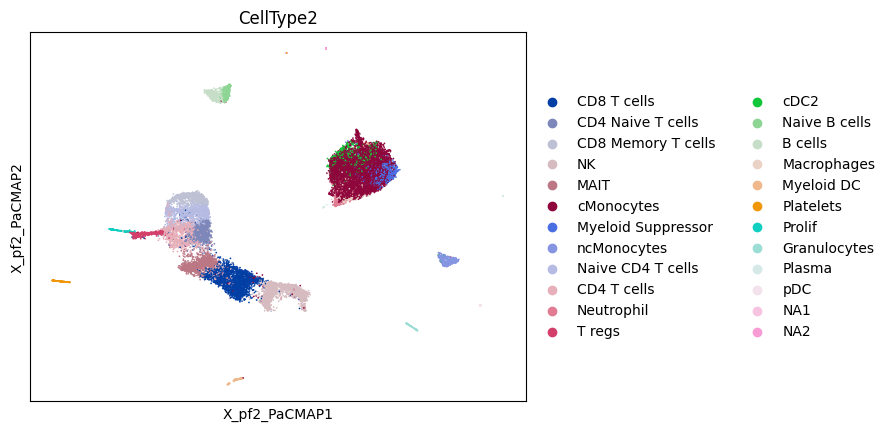

In [9]:
adata.obs["CellType2"] = adata.obs.leiden.replace(celltypedict_layer2)
data.obs["CellType1"] = data.obs.leiden.replace(celltypedict_layer2)
sc.pl.embedding(basis="X_pf2_PaCMAP", adata=adata, color=["CellType2"])

In [1]:
sc.pl.embedding(data, basis="X_pf2_PaCMAP", color=["SERPINF1"])

NameError: name 'sc' is not defined

In [10]:
data.write_h5ad("Cytokine_Pf2_annotated_NB.h5ad")

## PF2 PACMAPs

/home/brianoj/.cache/pypoetry/virtualenvs/sccp-rvA4szVo-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/brianoj/.cache/pypoetry/virtualenvs/sccp-rvA4szVo-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


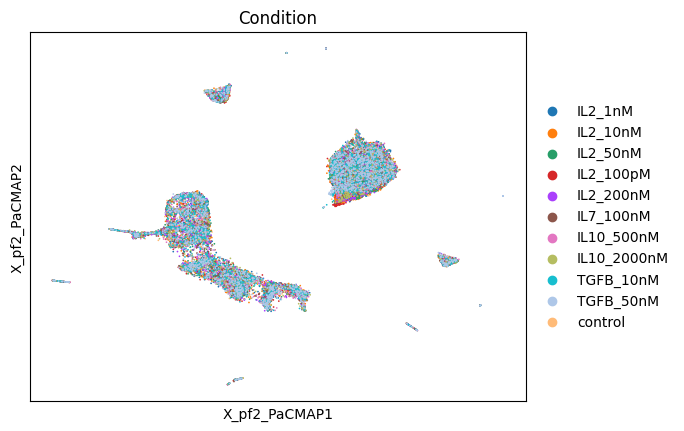

In [8]:
sc.pl.embedding(data, basis="X_pf2_PaCMAP", color=["Condition"])

/home/brianoj/.cache/pypoetry/virtualenvs/sccp-rvA4szVo-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/brianoj/.cache/pypoetry/virtualenvs/sccp-rvA4szVo-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


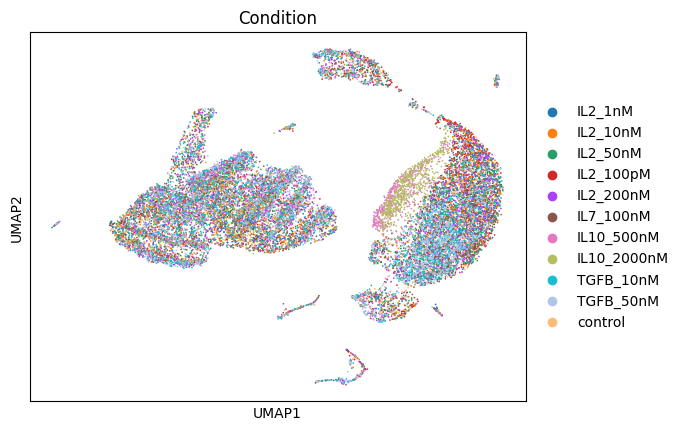

In [10]:
sc.pl.umap(data, color=["Condition"],)

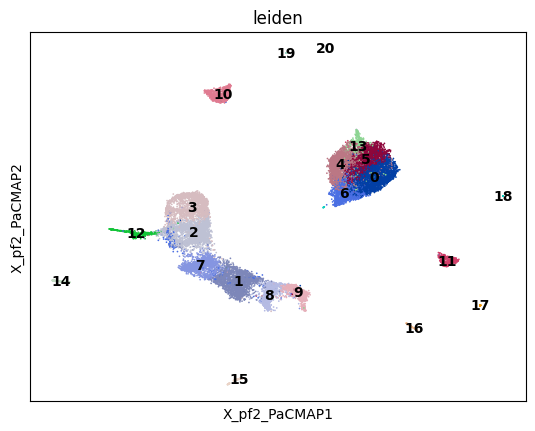

In [7]:
sc.pl.embedding(basis="X_pf2_PaCMAP", adata=data, color=["leiden"], legend_loc='on data')

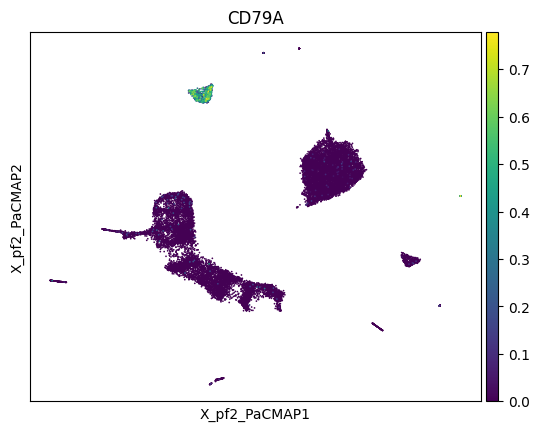

In [17]:
sc.pl.embedding(data, basis="X_pf2_PaCMAP", color=["CD79A"])

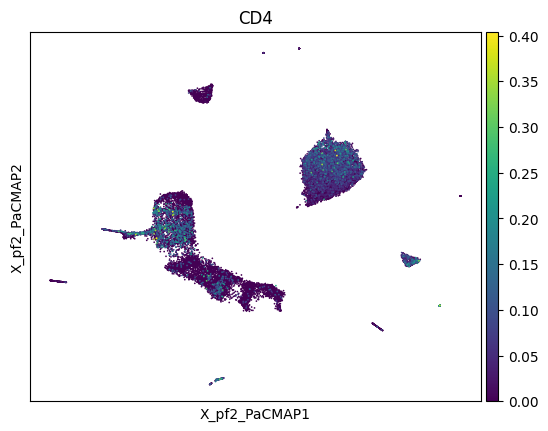

In [5]:
sc.pl.embedding(data, basis="X_pf2_PaCMAP", color=["CD4"])

## Annotation Start

In [8]:
sc.pp.highly_variable_genes(data, min_mean=0.0001, max_mean=10, min_disp=0.01)
data_l = data[:, data.var.highly_variable.values]

/home/nicoleb/Pf2-scRNAseq-1/.venv/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


In [9]:
print(data_l.obs.leiden.unique())

['3', '5', '2', '6', '1', ..., '18', '14', '20', '19', '17']
Length: 21
Categories (21, object): ['0', '1', '2', '3', ..., '17', '18', '19', '20']


KeyError: 'Could not find key CD79A in .var_names or .obs.columns.'

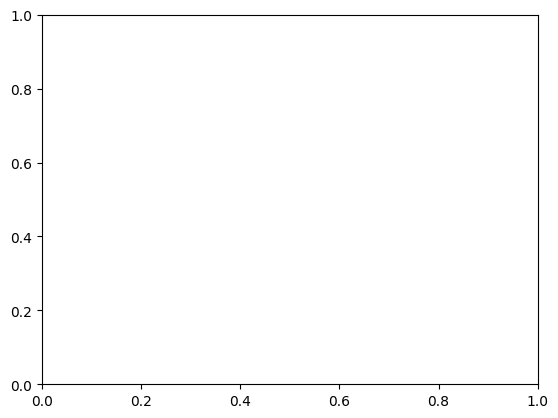

In [10]:
sc.pl.embedding(data_l, basis="X_pf2_PaCMAP", color=["CD79A"])

/home/brianoj/.cache/pypoetry/virtualenvs/sccp-rvA4szVo-py3.11/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/brianoj/.cache/pypoetry/virtualenvs/sccp-rvA4szVo-py3.11/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)
/home/brianoj/.cache/pypoetry/virtualenvs/sccp-rvA4szVo-py3.11/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To g

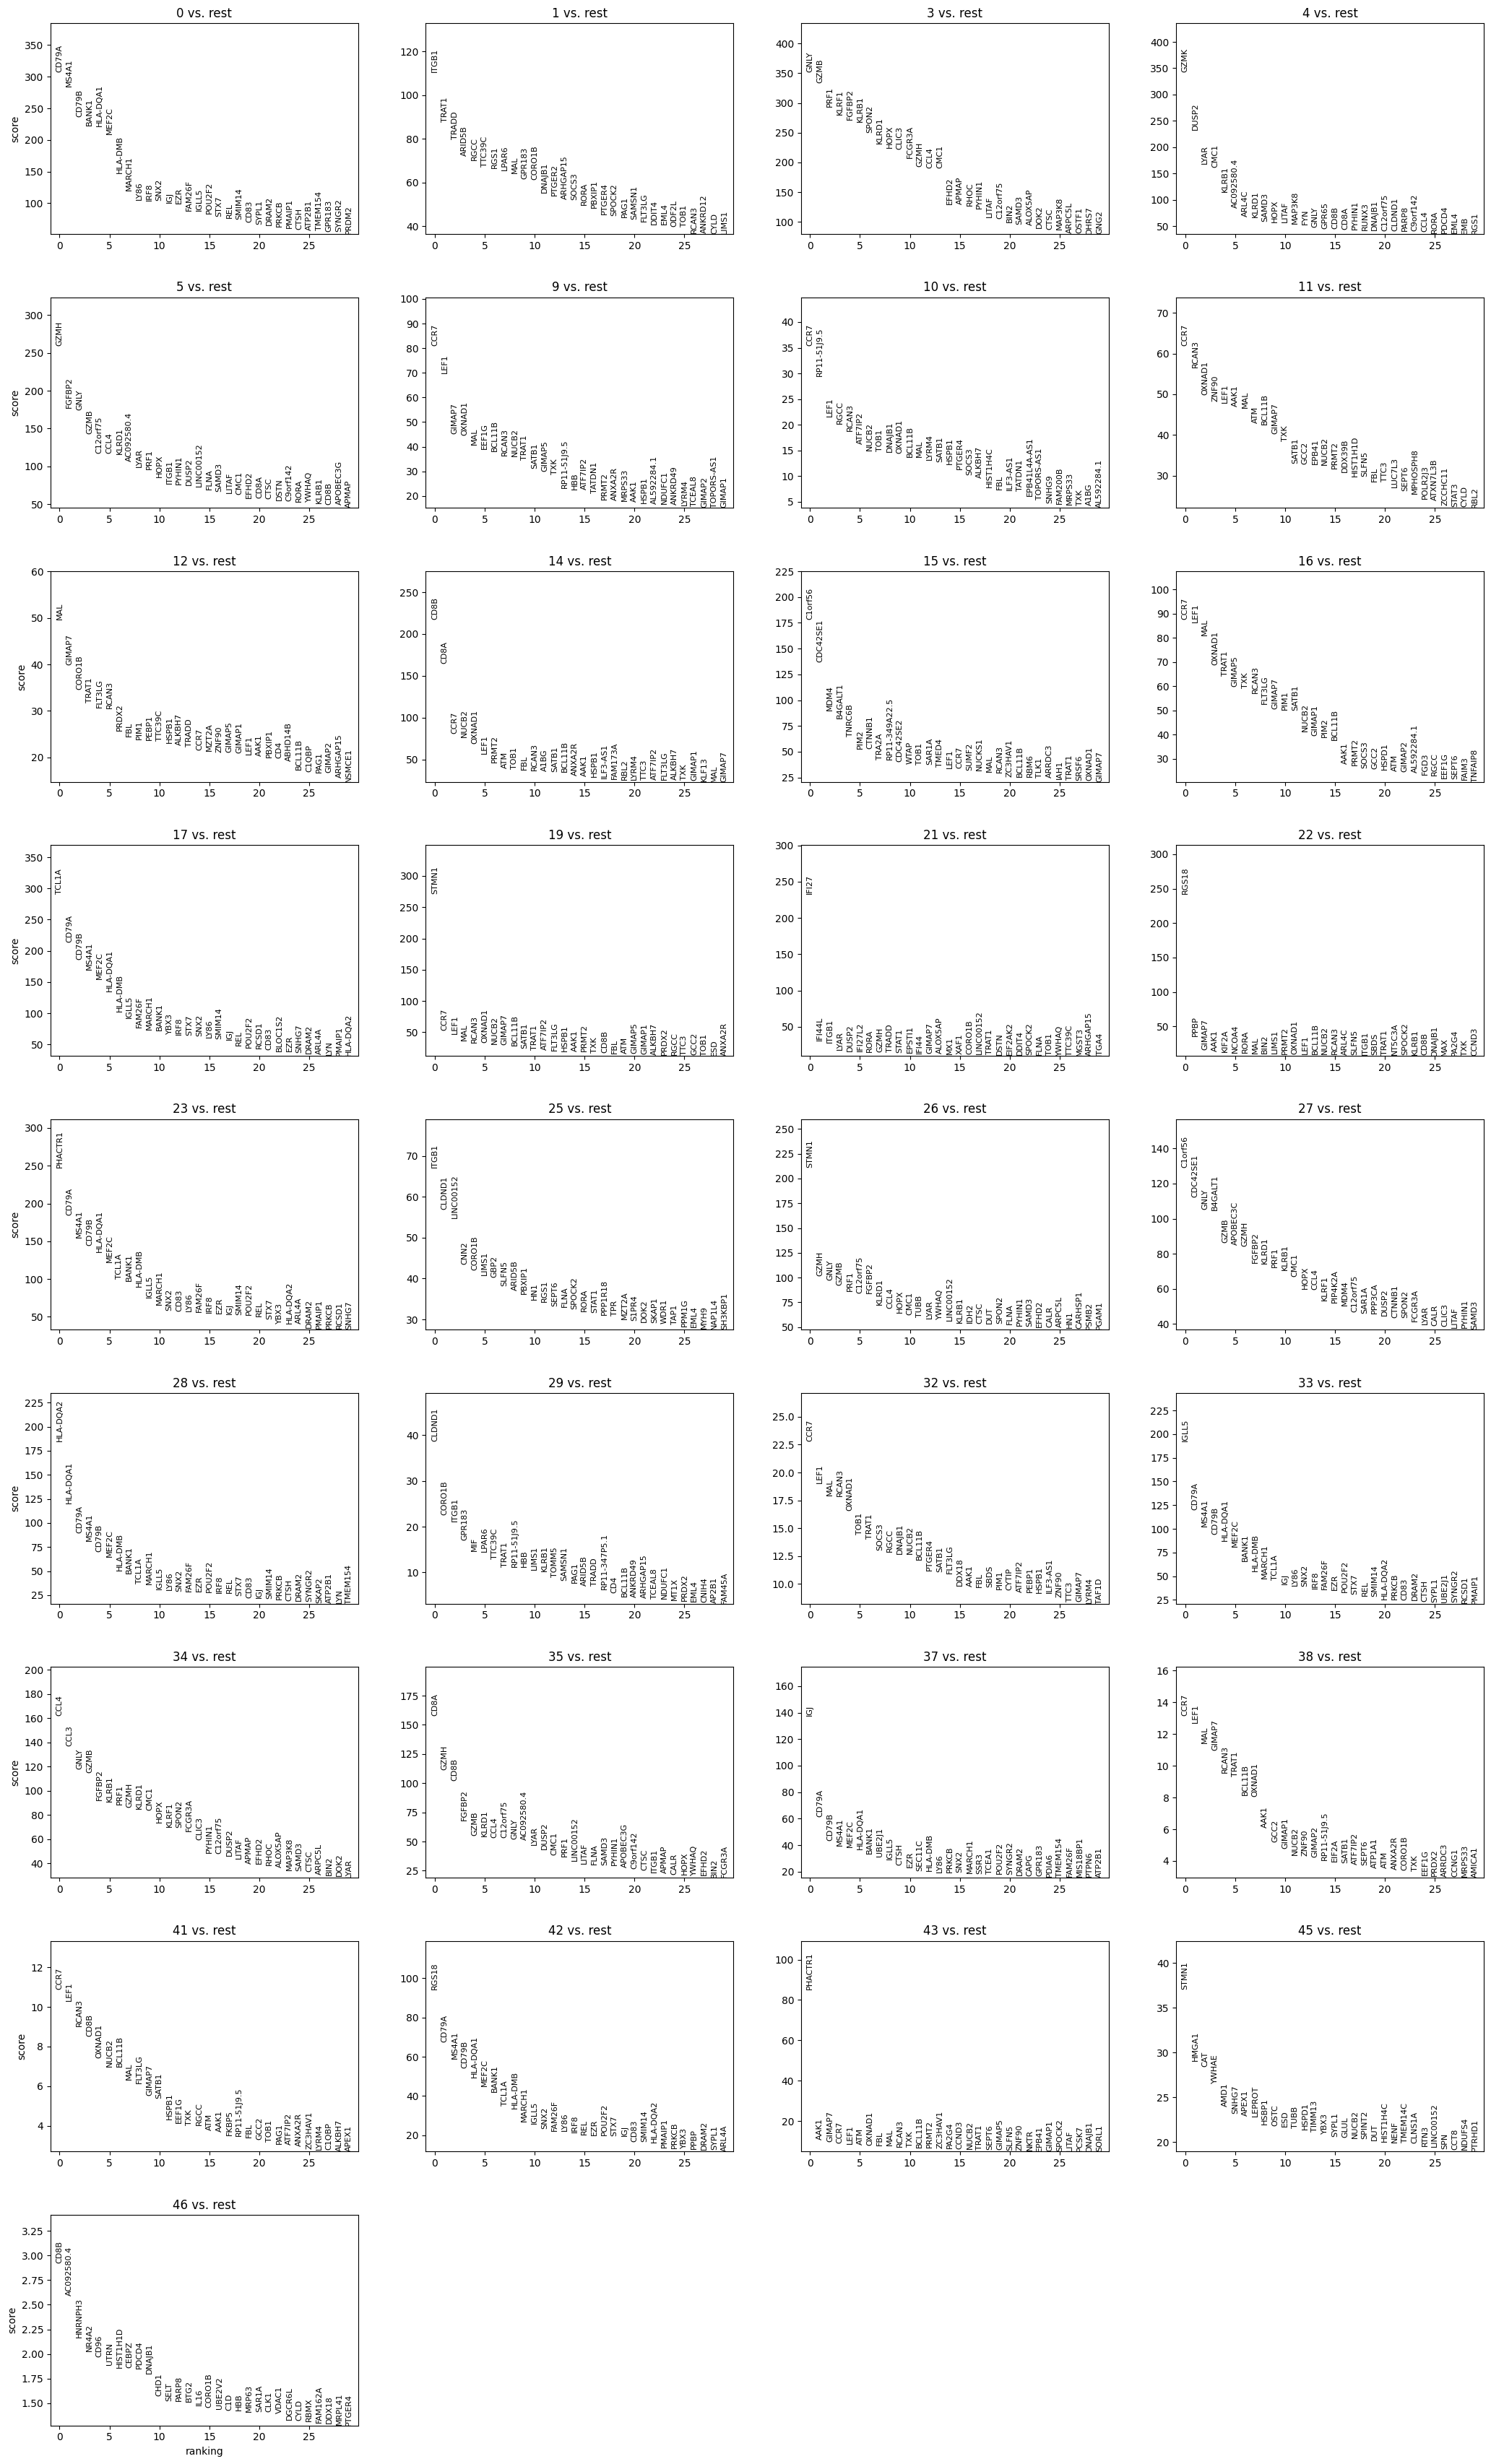

In [70]:
sc.tl.rank_genes_groups(data_l, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(data_l, n_genes=30, sharey=False, save=True)

In [71]:
celltypedict_layer2 = {"0": "B Naive", #nb-mature B cell?
                       "1": "T4 Naive",
                       "2": "CM", #Leave
                       "3": "NK Dim", #But a lot of NKG7 so maybe not?
                       "4": "T8 GZMK",
                       "5": "T8 GZMH",
                       "6": "CM", #Leave
                       "7": "CM", #Leave
                       "8": "nCM", #Leave
                       "9": "T4 Naive",
                       "10": "T4 Naive", #Treg
                       "11": "T4 Naive",
                       "12": "T4 EM", #Check
                       "13": "CM", #Leave
                       "14": "T8 Naive",
                       "15": "T4 Naive",
                       "16": "T4 Naive",
                       "17": "B Naive", #Treg
                       "18": "CM", #Leave
                       "19": "Prolif",
                       "20": "CM", #Leave
                       "21": "T4 EM", #Based on interferon response 
                       "22": "Null", 
                       "23": "B Naive", #No CD27 
                       "24": "cDC", #Leave
                       "25": "T4 Reg", #Based on interferon response 
                       "26": "T8 GZMH",
                       "27": "NK Dim",
                       "28": "B Mem",
                       "29": "T4 Reg", #Treg
                       "30": "CM", #Leave
                       "31": "CM", #Leave
                       "32": "T4 Naive", #Look again
                       "33": "B Plasma", 
                       "34": "NK Bright",
                       "35": "T8 GZMH",
                       "36": "CM", #Leave
                       "37": "B Plasma", 
                       "38": "T4 Naive",
                       "39": "pDC",
                       "40": "CM", #Leave
                       "41": "T4 Naive",
                       "42": "B Naive",
                       "43": "T4 Naive", #pDC?
                       "44": "CM",
                       "45": "Prolif",
                       "46": "T8 Naive", #Not sure
                       "47": "pDC",
                       }

data.obs["Cell Type2"] = data.obs.leiden.replace(celltypedict_layer2)

/tmp/ipykernel_390755/1865573002.py:51: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data.obs["Cell Type2"] = data.obs.leiden.replace(celltypedict_layer2)


/home/brianoj/.cache/pypoetry/virtualenvs/sccp-rvA4szVo-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


/home/brianoj/.cache/pypoetry/virtualenvs/sccp-rvA4szVo-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


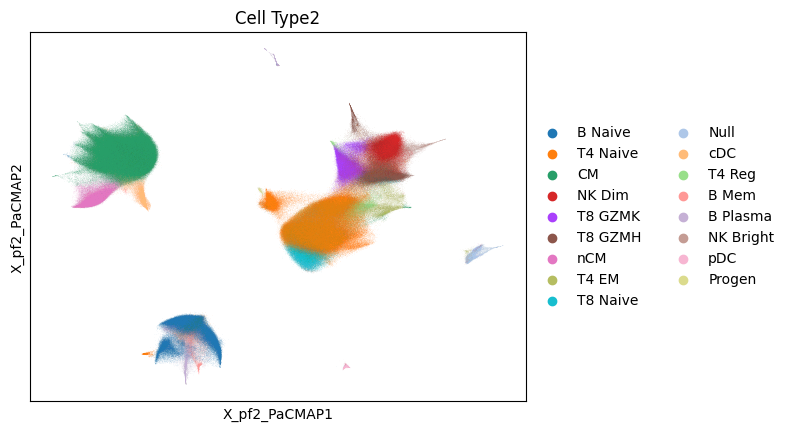

In [72]:
sc.pl.embedding(data, basis="X_pf2_PaCMAP", color=["Cell Type2"])

/home/brianoj/.cache/pypoetry/virtualenvs/sccp-rvA4szVo-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/brianoj/.cache/pypoetry/virtualenvs/sccp-rvA4szVo-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


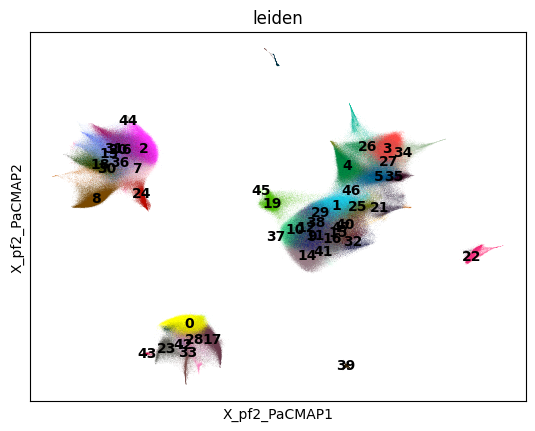

In [74]:
sc.pl.embedding(data, basis="X_pf2_PaCMAP", color=["leiden"], legend_loc="on data")

### Myeloid Compartment

In [75]:
data_m = an.read_h5ad("Lupus_Neighbors_10N_3R.h5ad")
data_m.obs["louvain_orig"] = data_m.obs["louvain"]
data_m.obs = data_m.obs.rename(columns={"Cell Type": "Cell Type Old"})
data_m.obs["Cell Type"] = data_m.obs.leiden.replace(celltypedict_layer1)
data_m = data[data.obs["Cell Type"].isin(["CM", "nCM", "cDC", "pDC"]).values, :]

/tmp/ipykernel_390755/3908648012.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data_m.obs["Cell Type"] = data_m.obs.leiden.replace(celltypedict_layer1)


/home/brianoj/.cache/pypoetry/virtualenvs/sccp-rvA4szVo-py3.11/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}
/home/brianoj/.cache/pypoetry/virtualenvs/sccp-rvA4szVo-py3.11/lib/python3.11/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


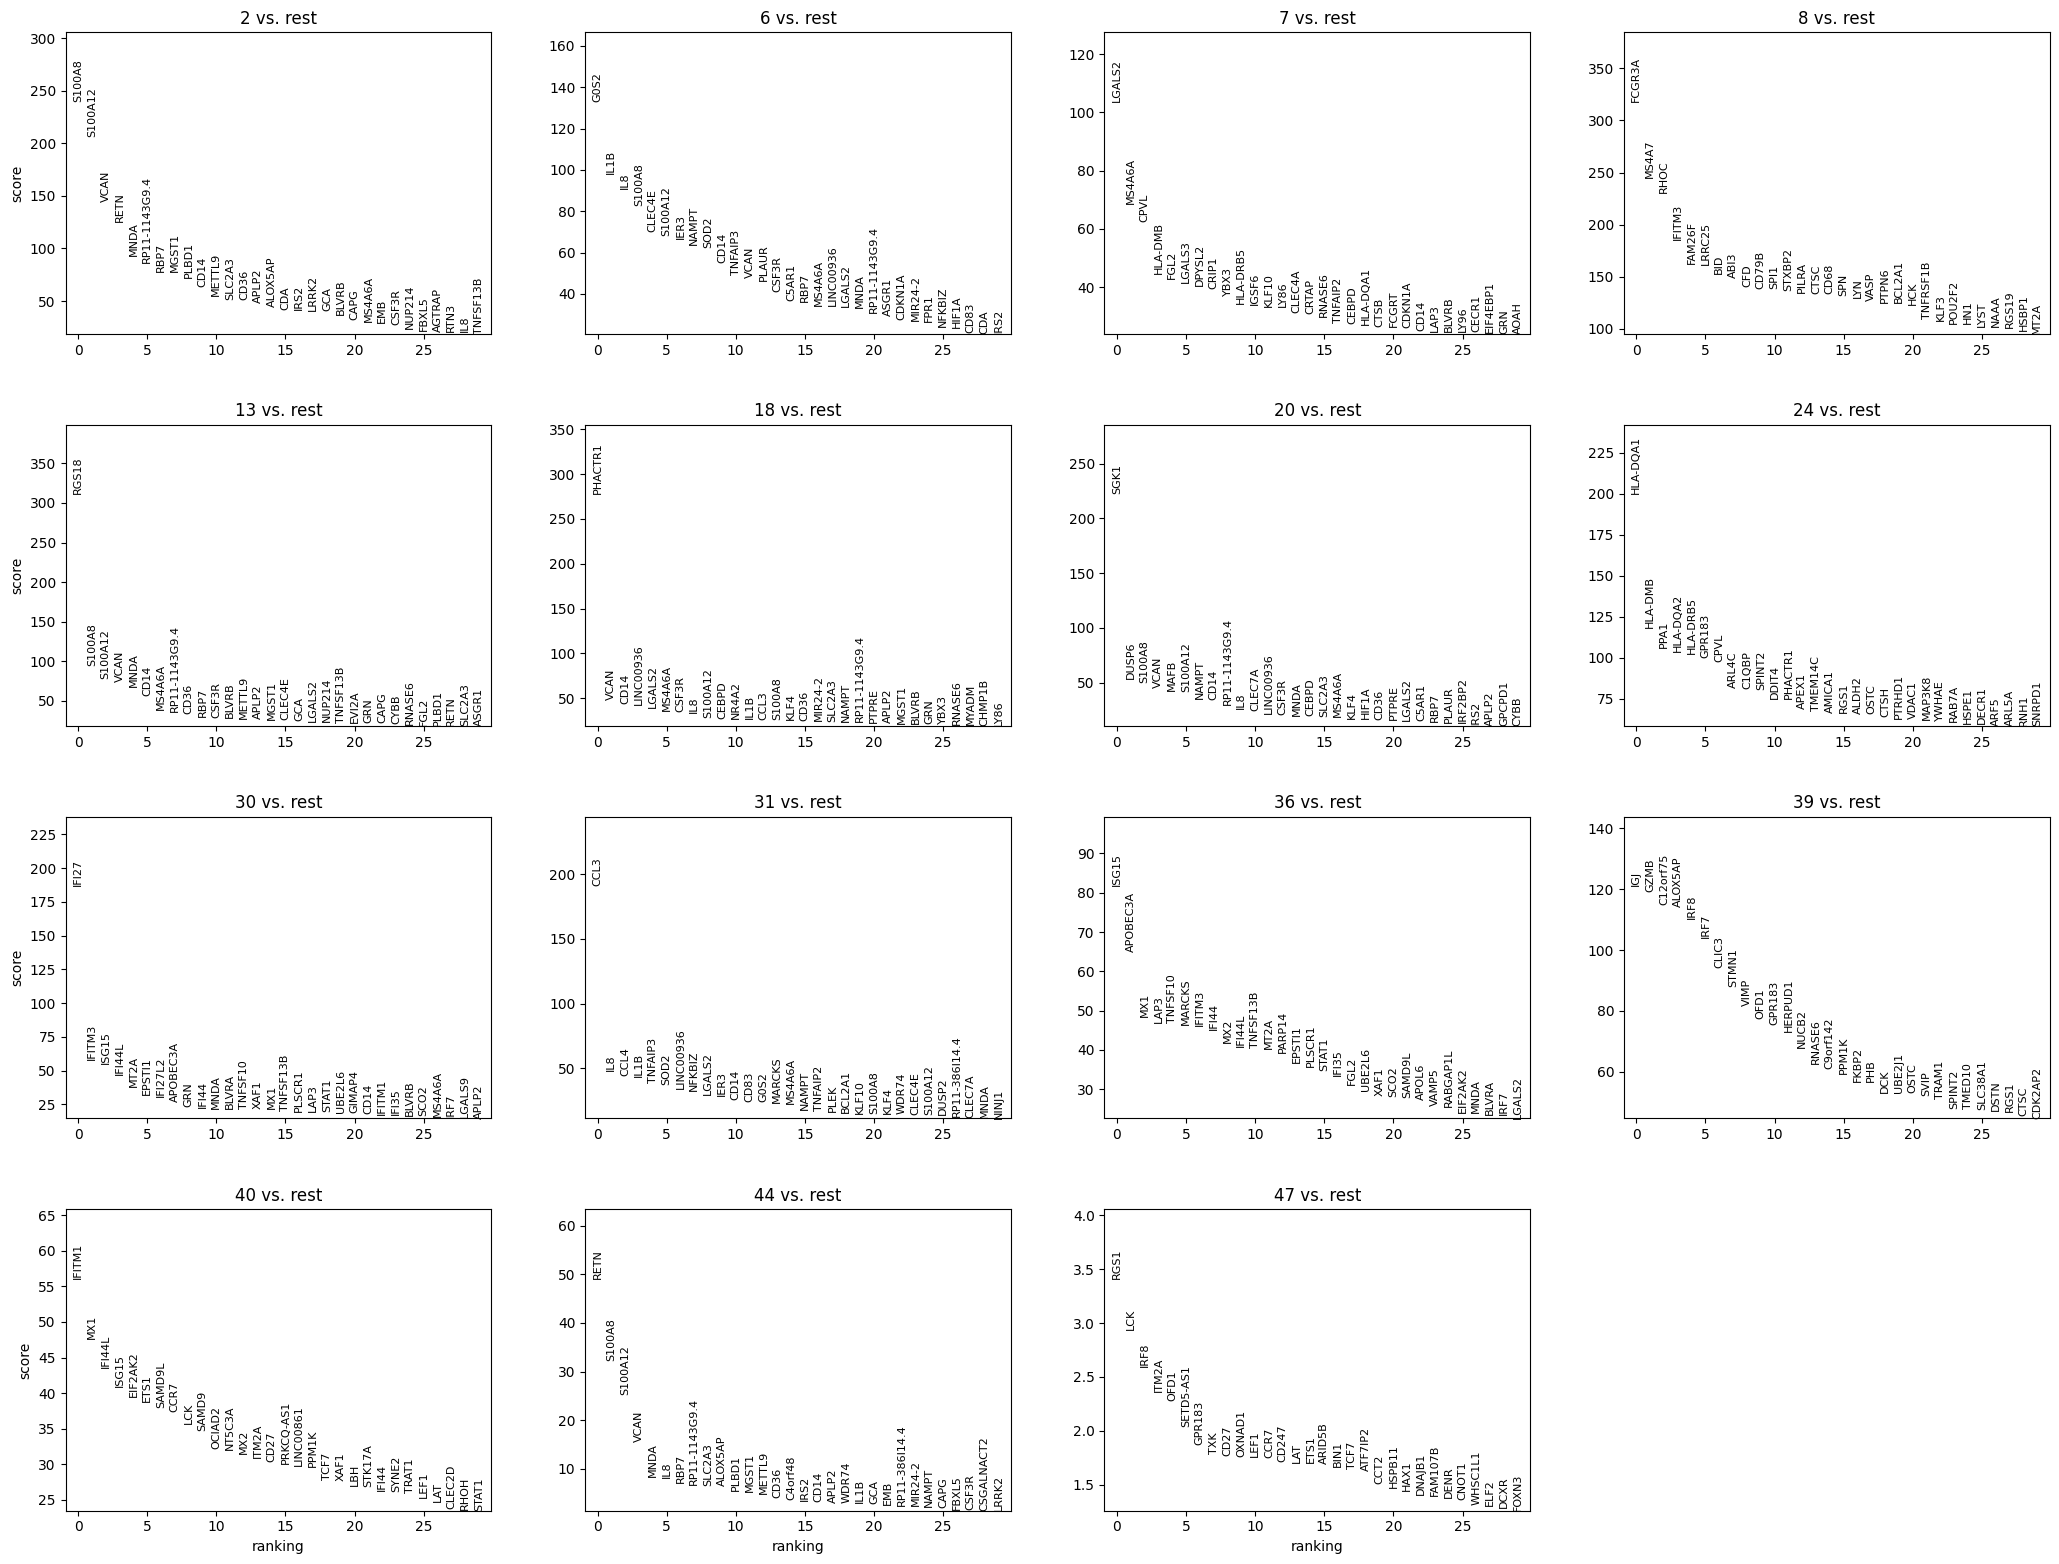

In [76]:
sc.tl.rank_genes_groups(data_m, 'leiden', method='wilcoxon')
sc.pl.rank_genes_groups(data_m, n_genes=30, sharey=False, save=True)

In [4]:
celltypedict_layer2 = {"0": "B Naive",
                       "1": "T4 Naive",
                       "2": "CM",
                       "3": "NK Dim",
                       "4": "T8 GZMK",
                       "5": "T8 GZMH",
                       "6": "CM",
                       "7": "cDC1",
                       "8": "nCM",
                       "9": "T4 Naive",
                       "10": "T4 Naive",
                       "11": "T4 Naive",
                       "12": "T4 EM",
                       "13": "CM",
                       "14": "T8 Naive",
                       "15": "T4 Naive",
                       "16": "T4 Naive",
                       "17": "B Naive",
                       "18": "CM",
                       "19": "Prolif",
                       "20": "CM",
                       "21": "T4 EM",
                       "22": "Null", 
                       "23": "B Naive",
                       "24": "cDC2",
                       "25": "T4 Reg",
                       "26": "T8 GZMH",
                       "27": "NK Dim",
                       "28": "B Mem",
                       "29": "T4 Reg",
                       "30": "CM",
                       "31": "CM",
                       "32": "T4 Naive", 
                       "33": "B Plasma", 
                       "34": "NK Bright",
                       "35": "T8 GZMH",
                       "36": "nCM",
                       "37": "B Plasma", 
                       "38": "T4 Naive",
                       "39": "pDC",
                       "40": "CM",
                       "41": "T4 Naive",
                       "42": "B Naive",
                       "43": "T4 Naive",
                       "44": "CM",
                       "45": "Prolif",
                       "46": "T8 Naive",
                       "47": "pDC",
                       }


data.obs["Cell Type2"] = data.obs.leiden.replace(celltypedict_layer2)

/tmp/ipykernel_959565/1947409935.py:52: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data.obs["Cell Type2"] = data.obs.leiden.replace(celltypedict_layer2)


/home/brianoj/.cache/pypoetry/virtualenvs/sccp-rvA4szVo-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/brianoj/.cache/pypoetry/virtualenvs/sccp-rvA4szVo-py3.11/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


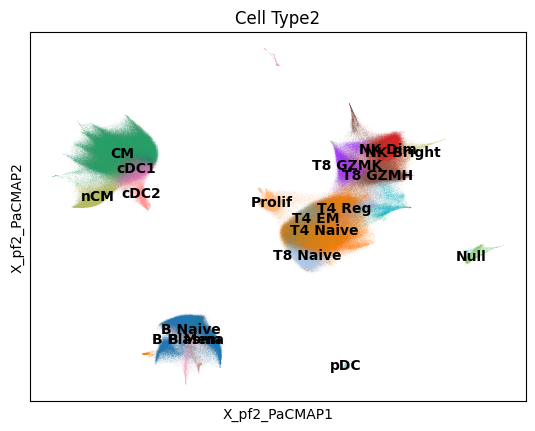

In [5]:
sc.pl.embedding(data, basis="X_pf2_PaCMAP", color=["Cell Type2"], legend_loc="on data")

In [6]:
print(data)

AnnData object with n_obs × n_vars = 1263673 × 2161
    obs: 'pool', 'patient', 'Processing_Cohort', 'louvain', 'Cell Type Old', 'cell_type_lympho', 'L3', 'Condition', 'age', 'sex', 'ancestry', 'Status', 'SLE_status', 'CD103|ITGAE', 'CD137|TNFRSF9', 'CD274|CD274', 'CD11b|ITGAM', 'CD39|ENTPD1', 'CD197|CCR7', 'CD20|MS4A1', 'CD45RA|PTPRC', 'CD69|CD69', 'CD275|ICOSLG', 'CD278|ICOS', 'CD134|TNFRSF4', 'CD279|PDCD1', 'TCRgd|TRD_TRG', 'Tim3|HAVCR2', 'CD152|CTLA4', 'CD223|LAG3', 'CD56|NCAM1', 'CD123|IL3RA', 'CD81|CD81', 'CD38|CD38', 'CD95|FAS', 'CD28|CD28', 'CD27|CD27', 'CD25|IL2RA', 'CD8|CD8A', 'CD127|IL7R', 'CD2|CD2', 'CD19|CD19', 'CD183|CXCR3', 'CD4|CD4', 'CD3|CD3E', 'CD196|CCR6', 'CD45RO|PTPRC', 'CD14|CD14', 'CD194|CCR4', 'CD185|CXCR5', 'CD45|PTPRC', 'CD24|CD24', 'CD7|CD7', 'CD33|CD33', 'CD90|THY1', 'CD80|CD80', 'CD5|CD5', 'CD235a_b|GYPA_GYPB', 'CD62L|SELL', 'CD13|ANPEP', 'CD10|MME', 'CD272|BTLA', 'CD16|FCGR3A', 'CD44|CD44', 'CD11c|ITGAX', 'CD86|CD86', 'IgD|IGHD', 'IgG|IGHG1_2_3_4', 'CD184|

### Save Cell Types

In [7]:
cellDF = data.obs[["Cell Type", "Cell Type2"]]
cellDF.columns = ["Cell Type", "Cell Type2"]
cellDF.index.name = None
cellDF.to_csv("LupusCellTypesFinal.csv")
data.write_h5ad("Lupus_Annotated_Final_Updated.h5ad")

In [ ]:
"""
celltypedict_layer1 = {"0": "NK",
                       "1": "B",
                       "2": "T8", #Questiomable
                       "3": "T4",
                       "4": "T8",
                       "5": "T4",
                       "6": "T8",
                       "7": "CM",
                       "8": "nCM",
                       "9": "T4",
                       "10": "T4", #Treg
                       "11": "T4",
                       "12": "CM",
                       "13": "CM",
                       "14": "CM",
                       "15": "T4",
                       "16": "B",
                       "17": "T4", #Treg
                       "18": "CM",
                       "19": "Prolif",
                       "20": "CM",
                       "21": "CM",
                       "22": "T4", #Questionable
                       "23": "T4", #Questionable
                       "24": "B",
                       "25": "Prolif",
                       "26": "NK",
                       "27": "cDC",
                       "28": "cDC",
                       "29": "CM",
                       "30": "nCM", #Intermediate
                       "31": "T4", #Questionable
                       "32": "B", 
                       "33": "CM", #Neutrophil
                       "34": "B",
                       "35": "PB",
                       "36": "T4",
                       "37": "pDC", #Questionable
                       "38": "Prolif",
                       "39": "B",
                       "40": "B",
                       "41": "T4",
                       "42": "Prolif",
                       "43": "pDC",
                       "44": "pDC",
                       "45": "pDC",
                       "46": "pDC",
                       "47": "pDC",
                       }
"""